# HEMC : Stage 1 (HMR + RTC, with/without CRF-Viterbi) + Stage 2 (RTC, fixation vs microsaccade)

In [20]:
import os
os.environ.setdefault("OBJC_DISABLE_INITIALIZE_FORK_SAFETY", "YES")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import sys
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PUPIL_ROOT = Path.cwd()
HEMC_SRC = PUPIL_ROOT / "src"
if not (HEMC_SRC / "hemc").exists():
    raise RuntimeError(
        f"Package hemc not found in {HEMC_SRC}. Adjust PUPIL_ROOT."
    )
sys.path.insert(0, str(HEMC_SRC))

from hemc.data import RecordingMeta, group_train_val_test_split, sample_train_val_test_split, iterate_hmr
from hemc.features import extract_emccfpp_features_df, extract_auxiliary_signal_features_df
from hemc.models import (
    CascadeForestClassifier, SequentialCRFDecoder,
    build_transition_matrix, estimate_mean_durations_ms, estimate_transition_counts, viterbi_decode,
)
from hemc.eval import pointwise_report, event_wise_report
from hemc.utils import set_global_seed

CLASSES_4 = ["F", "S", "P", "B"]  # Fixation, Saccade, Smooth Pursuit, Blink
set_global_seed(42)

DATA_ROOT = PUPIL_ROOT / "Data"
HMR_ROOT = DATA_ROOT / "data_hmr"
RTC_ROOT = DATA_ROOT / "data_RTC"
CACHE_ROOT = PUPIL_ROOT / "cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print(f"HMR_ROOT = {HMR_ROOT} (exists: {HMR_ROOT.exists()})")
print(f"RTC_ROOT = {RTC_ROOT} (exists: {RTC_ROOT.exists()})")

HMR_ROOT = /Users/hanaehammani/HEMC_model/Data/data_hmr (exists: True)
RTC_ROOT = /Users/hanaehammani/HEMC_model/Data/data_RTC (exists: True)


## Configuration

In [21]:
QUICK = True  # True = quick run  ; False = complete run  

RANDOM_STATE = 42
N_ESTIMATORS = 15 if QUICK else 150
MAX_LAYERS = 3 if QUICK else 10
N_JOBS = 1

LIMIT_HMR = 8 if QUICK else None    # 8 recordings = 4 subjects 
LIMIT_RTC = 8 if QUICK else None    # 8 files = 4 participants 

FS_HZ_HMR = 200.0
FS_HZ_RTC = 200.0  

print(f"QUICK={QUICK} | N_ESTIMATORS={N_ESTIMATORS} | MAX_LAYERS={MAX_LAYERS} | N_JOBS={N_JOBS}")
print(f"LIMIT_HMR={LIMIT_HMR} | LIMIT_RTC={LIMIT_RTC}")


QUICK=True | N_ESTIMATORS=15 | MAX_LAYERS=3 | N_JOBS=1
LIMIT_HMR=8 | LIMIT_RTC=8


## Features


In [23]:
RTC_LABEL_MAP = {
    "fixation": "F", "saccade": "S", "microsaccade": "S",
    "smooth_pursuit": "P", "blink": "B",
}

RTC_AUX_RAW_COLUMNS = [
    "pupil diameter left [mm]", "pupil diameter right [mm]",
    "eyelid aperture left [mm]", "eyelid aperture right [mm]",
    "azimuth [deg]", "elevation [deg]", "timestamp_sec",
]


def _gaze_angular_velocity_deg_s(azimuth_deg: np.ndarray, elevation_deg: np.ndarray, timestamp_sec: np.ndarray) -> np.ndarray:
    diffs_t = np.diff(timestamp_sec)
    dt = np.concatenate([[diffs_t[0] if len(diffs_t) else 1.0 / FS_HZ_RTC], diffs_t])
    dt = np.where(dt <= 0, 1.0 / FS_HZ_RTC, dt)  # safeguard: timestamps not strictly increasing
    d_az = np.diff(azimuth_deg, prepend=azimuth_deg[0])
    d_el = np.diff(elevation_deg, prepend=elevation_deg[0])
    return np.hypot(d_az, d_el) / dt


def load_rtc_recording(path: Path) -> tuple[pd.DataFrame, RecordingMeta]:
    raw = pd.read_csv(path, usecols=["gaze x [px]", "gaze y [px]", "Class", *RTC_AUX_RAW_COLUMNS])
    subject = re.sub(r"_SU[Tt]\d+$", "", path.stem)  # "Mathilde_SUT1" -> "Mathilde"
    recording_id = path.stem
    eyelid_left = raw["eyelid aperture left [mm]"].to_numpy(dtype=float)
    eyelid_right = raw["eyelid aperture right [mm]"].to_numpy(dtype=float)
    angular_velocity = _gaze_angular_velocity_deg_s(
        raw["azimuth [deg]"].to_numpy(dtype=float),
        raw["elevation [deg]"].to_numpy(dtype=float),
        raw["timestamp_sec"].to_numpy(dtype=float),
    )
    df = pd.DataFrame({
        "x": raw["gaze x [px]"].to_numpy(dtype=float),
        "y": raw["gaze y [px]"].to_numpy(dtype=float),
        "label": raw["Class"].map(RTC_LABEL_MAP),  # NaN for "noise" -> filtered out below
        "label_raw": raw["Class"].to_numpy(),  # keeps "fixation"/"microsaccade" distinct, for Stage 2
        "eyelid_aperture_mean": (eyelid_left + eyelid_right) / 2.0,
        "eyelid_aperture_min": np.minimum(eyelid_left, eyelid_right),  # also captures an asymmetric/partial blink
        "pupil_diameter_mean": (raw["pupil diameter left [mm]"].to_numpy(dtype=float)
                                 + raw["pupil diameter right [mm]"].to_numpy(dtype=float)) / 2.0,
        "gaze_angular_velocity_deg_s": angular_velocity,
    })
    meta = RecordingMeta(dataset="rtc", recording_id=recording_id, subject=subject, group=subject, fs_hz=FS_HZ_RTC)
    return df, meta


def iterate_rtc(root: Path = RTC_ROOT):
    for csv_path in sorted(root.glob("*.csv")):
        yield load_rtc_recording(csv_path)


RTC_BLINK_AUX_COLUMNS = ["eyelid_aperture_mean", "eyelid_aperture_min", "pupil_diameter_mean"]
RTC_BLINK_AUX_WITH_RATE = {"eyelid_aperture_mean"}  
RTC_SP_AUX_COLUMNS = ["gaze_angular_velocity_deg_s"]
RTC_SP_AUX_WITH_RATE = {"gaze_angular_velocity_deg_s"} 


def get_or_compute_features(dataset: str, df: pd.DataFrame, meta: RecordingMeta) -> pd.DataFrame:
    path = CACHE_ROOT / dataset / "emccfpp" / f"{meta.recording_id}.parquet"
    if path.exists():
        return pd.read_parquet(path)
    feats = extract_emccfpp_features_df(df, meta.fs_hz)
    aux_columns = RTC_BLINK_AUX_COLUMNS + RTC_SP_AUX_COLUMNS
    if all(c in df.columns for c in aux_columns):
        aux_blink = extract_auxiliary_signal_features_df(
            df, RTC_BLINK_AUX_COLUMNS, meta.fs_hz, with_rate=RTC_BLINK_AUX_WITH_RATE)
        aux_sp = extract_auxiliary_signal_features_df(
            df, RTC_SP_AUX_COLUMNS, meta.fs_hz, with_rate=RTC_SP_AUX_WITH_RATE)
        feats = pd.concat([feats, aux_blink, aux_sp], axis=1)
    feats["label"] = df["label"].to_numpy()
    feats["group"] = meta.group
    feats["recording_id"] = meta.recording_id
    feats["subject"] = meta.subject
    path.parent.mkdir(parents=True, exist_ok=True)
    feats.to_parquet(path)
    return feats


def build_dataset_table(dataset: str, iterator, limit: int | None = None, verbose: bool = True) -> pd.DataFrame:
    frames = []
    for i, (df, meta) in enumerate(iterator):
        if limit is not None and i >= limit:
            break
        if verbose:
            print(f"  [{dataset}] {meta.recording_id} ({len(df)} samples)")
        frames.append(get_or_compute_features(dataset, df, meta))
    table = pd.concat(frames, axis=0, ignore_index=True)
    n_before = len(table)
    table = table[table["label"].isin(CLASSES_4)].reset_index(drop=True)
    n_dropped = n_before - len(table)
    if n_dropped:
        print(f"  {n_dropped} sample(s) outside {CLASSES_4} dropped (e.g. 'noise' RTC).")
    return table


# --- Event-wise metrics
def aggregate_event_reports(reports, class_names):
    rows = []
    for c in class_names:
        n_true = sum(r.loc[c, "n_true_events"] for r in reports)
        n_pred = sum(r.loc[c, "n_pred_events"] for r in reports)
        n_matched = sum(round(r.loc[c, "event_precision"] * r.loc[c, "n_pred_events"]) for r in reports)
        precision = n_matched / n_pred if n_pred > 0 else 0.0
        recall = n_matched / n_true if n_true > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        oversegmentation = n_pred / n_true if n_true > 0 else float("nan")
        rows.append({"class": c, "n_true_events": n_true, "n_pred_events": n_pred,
                      "event_precision": precision, "event_recall": recall, "event_f1": f1,
                      "oversegmentation_ratio": oversegmentation})
    return pd.DataFrame(rows).set_index("class")


def evaluate_split(clf, table, X, y, test_mask, classes, label, show_oversegmentation=True):
    '''Evaluate split sample-wise and event-wise'''

    y_pred = clf.predict(X[test_mask])
    sample_report = pointwise_report(y[test_mask], y_pred, classes)

    test_table = table[test_mask].copy()
    test_table["pred"] = y_pred
    event_reports = [
        event_wise_report(g["pred"].to_numpy(), g["label"].to_numpy(), classes)
        for _, g in test_table.groupby("recording_id", sort=False)
    ]
    event_report = aggregate_event_reports(event_reports, classes)

    print(f"=== {label} -- sample-wise ===")
    display(sample_report.round(4))
    print(f"\n=== {label} -- by event ===")
    if not show_oversegmentation:
        print(" ratio of over-segmentation ")
        display(event_report.drop(columns=["oversegmentation_ratio"]).round(4))
    else:
        display(event_report.round(4))
    return sample_report, event_report, y_pred


# --- split group -> cascade forest -> CRF-Viterbi --
def run_group_split_with_crf(table, X, y, feature_cols, classes, fs_hz,
                              n_estimators, max_layers, n_jobs, random_state, context_k=5,
                              show_performance=True):
    # split by participant/recording 
    split_group = group_train_val_test_split(table["group"].tolist(), seed=random_state)
    train_mask = table["group"].isin(split_group.train_groups).to_numpy()
    val_mask = table["group"].isin(split_group.val_groups).to_numpy()
    test_mask = table["group"].isin(split_group.test_groups).to_numpy()
    non_test_mask = ~test_mask
    print(f"Group split -- train={train_mask.sum()}, val={val_mask.sum()}, test={test_mask.sum()}")

    clf = CascadeForestClassifier(n_estimators_per_forest=n_estimators, max_layers=max_layers,
                                   random_state=random_state, n_jobs=n_jobs)
    clf.fit(X[train_mask], y[train_mask], X[val_mask], y[val_mask])
    class_order = [list(clf.classes_).index(c) for c in classes]

    # --- CRF-Viterbi 
    non_test_label_seqs = [g["label"].to_numpy() for _, g in table[non_test_mask].groupby("recording_id", sort=False)]
    mean_durations_ms = estimate_mean_durations_ms(non_test_label_seqs, classes, fs_hz)
    transition_counts = estimate_transition_counts(non_test_label_seqs, classes)
    transition_matrix = build_transition_matrix(classes, mean_durations_ms, fs_hz, transition_counts)
    print(f"Physiological duration (ms) : {mean_durations_ms}")

    decoder = SequentialCRFDecoder(class_names=classes, context_k=context_k, random_state=random_state)
    context_feats_list, y_context_list = [], []
    for _, g in table[non_test_mask].groupby("recording_id", sort=False):
        proba_seq = clf.predict_proba(g[feature_cols].to_numpy())[:, class_order]
        context_feats_list.append(decoder.build_context_features(proba_seq, mean_durations_ms, fs_hz))
        y_context_list.append(g["label"].to_numpy())
    decoder.fit(np.concatenate(context_feats_list, axis=0), np.concatenate(y_context_list, axis=0))
    print("CRF trained.")

    # --- evaluation before / after CRF 
    y_pred_before_list, y_pred_after_list, y_true_list = [], [], []
    for _, g in table[test_mask].groupby("recording_id", sort=False):
        proba_seq = clf.predict_proba(g[feature_cols].to_numpy())[:, class_order]
        pred_before = np.array(classes)[proba_seq.argmax(axis=1)]
        feats = decoder.build_context_features(proba_seq, mean_durations_ms, fs_hz)
        smoothed_proba = decoder.predict_proba(feats)
        log_proba = np.log(np.clip(smoothed_proba, 1e-12, 1.0))
        pred_after = np.array(viterbi_decode(log_proba, transition_matrix, classes))

        y_pred_before_list.append(pred_before)
        y_pred_after_list.append(pred_after)
        y_true_list.append(g["label"].to_numpy())

    y_true = np.concatenate(y_true_list)
    report_before = pointwise_report(y_true, np.concatenate(y_pred_before_list), classes)
    report_after = pointwise_report(y_true, np.concatenate(y_pred_after_list), classes)

    event_reports_before = [event_wise_report(p, t, classes) for p, t in zip(y_pred_before_list, y_true_list)]
    event_reports_after = [event_wise_report(p, t, classes) for p, t in zip(y_pred_after_list, y_true_list)]
    agg_before = aggregate_event_reports(event_reports_before, classes)
    agg_after = aggregate_event_reports(event_reports_after, classes)

    event_display_cols = (
        ["n_true_events", "n_pred_events", "event_precision", "event_recall", "event_f1", "oversegmentation_ratio"]
        if show_performance
        else ["n_true_events", "n_pred_events", "oversegmentation_ratio"]
    )
    print("\n=== BEFORE CRF-Viterbi (split group) -- by event ===")
    display(agg_before[event_display_cols].round(4))
    print("\n=== AFTER CRF-Viterbi (split group) -- by event ===")
    display(agg_after[event_display_cols].round(4))

    return {
        "clf": clf, "decoder": decoder, "transition_matrix": transition_matrix, "mean_durations_ms": mean_durations_ms,
        "train_mask": train_mask, "val_mask": val_mask, "test_mask": test_mask,
        "report_before": report_before, "report_after": report_after,
        "agg_before": agg_before, "agg_after": agg_after,
    }


def compare_sample_vs_event(name, classes, result):

    xpos = np.arange(len(classes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(xpos - width / 2, result["agg_before"].loc[classes, "event_f1"], width, label="group split -- before CRF")
    ax.bar(xpos + width / 2, result["agg_after"].loc[classes, "event_f1"], width, label="group split -- after CRF")
    ax.set_xticks(xpos); ax.set_xticklabels(classes)
    ax.set_ylabel("F1 (by event, IoU >= 0.5)")
    ax.set_title(f"{name} -- F1 event-wise, before/after CRF-Viterbi (group split)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    delta_sample = result["report_after"].loc["macro_avg", "f1"] - result["report_before"].loc["macro_avg", "f1"]
    delta_event = result["agg_after"]["event_f1"].mean() - result["agg_before"]["event_f1"].mean()
    print(f"[{name}] Macro-F1 gain from CRF-Viterbi (group split) -- "
          f"sample-wise: {delta_sample:+.4f} | event-wise: {delta_event:+.4f}")
    return delta_sample, delta_event


def plot_oversegmentation(name, classes, result):

    xpos = np.arange(len(classes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(xpos - width / 2, result["agg_before"].loc[classes, "oversegmentation_ratio"], width,
           label="group split -- before CRF")
    ax.bar(xpos + width / 2, result["agg_after"].loc[classes, "oversegmentation_ratio"], width,
           label="group split -- after CRF")
    ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="1.0 = no over-segmentation")
    ax.set_xticks(xpos); ax.set_xticklabels(classes)
    ax.set_ylabel("Over-segmentation ratio\n(predicted events / true events)")
    ax.set_title(f"{name} -- over-segmentation, before/after CRF-Viterbi (group split)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    over_before = result["agg_before"].loc[classes, "oversegmentation_ratio"].mean()
    over_after = result["agg_after"].loc[classes, "oversegmentation_ratio"].mean()
    print(f"[{name}] Average over-segmentation (macro, group split) -- before CRF: {over_before:.3f} | "
          f"after CRF: {over_after:.3f} | reduction: {over_before - over_after:+.3f}")
    return over_before, over_after


def _tag(df, tag):
    d = df.copy()
    d.insert(0, "step", tag)
    return d


def recap_table(classes, result):
    
    labels_x = classes + ["macro_avg"]
    sample_compare = pd.concat([
        _tag(result["report_before"].loc[labels_x, ["precision", "recall", "f1", "support"]], "group split -- before CRF"),
        _tag(result["report_after"].loc[labels_x, ["precision", "recall", "f1", "support"]], "group split -- after CRF"),
    ])
    event_compare = pd.concat([
        _tag(result["agg_before"][["event_precision", "event_recall", "event_f1", "oversegmentation_ratio"]], "group split -- before CRF"),
        _tag(result["agg_after"][["event_precision", "event_recall", "event_f1", "oversegmentation_ratio"]], "group split -- after CRF"),
    ])
    print("=== Sample-wise comparison (precision/recall/F1 by class + macro_avg) ===")
    display(sample_compare.round(4))
    print("\n=== Event-wise comparison (by class) -- before/after CRF, over-segmentation ratio included ===")
    display(event_compare.round(4))
    return sample_compare, event_compare


def oversegmentation_table(classes, result):
    event_compare = pd.concat([
        _tag(result["agg_before"][["n_true_events", "n_pred_events", "oversegmentation_ratio"]], "group split -- before CRF"),
        _tag(result["agg_after"][["n_true_events", "n_pred_events", "oversegmentation_ratio"]], "group split -- after CRF"),
    ])
    print("=== Over-segmentation by class -- before/after CRF-Viterbi (group split) ===")
    display(event_compare.round(4))
    return event_compare


## Dataset 1 -- HMR

In [27]:
table_hmr = build_dataset_table("hmr", iterate_hmr(HMR_ROOT), limit=LIMIT_HMR)
feature_cols_hmr = [c for c in table_hmr.columns if c not in ("label", "group", "recording_id", "subject")]
X_hmr = table_hmr[feature_cols_hmr].to_numpy()
y_hmr = table_hmr["label"].to_numpy()

print(f"\n{len(table_hmr)} samples, {len(feature_cols_hmr)} features, "
      f"{table_hmr['recording_id'].nunique()} recordings, {table_hmr['group'].nunique()} subjects.")
print(table_hmr["label"].value_counts())

  [hmr] user_1_eye_0 (58255 samples)
  [hmr] user_1_eye_1 (58244 samples)
  [hmr] user_10_eye_0 (52029 samples)
  [hmr] user_10_eye_1 (52029 samples)
  [hmr] user_11_eye_0 (53895 samples)
  [hmr] user_11_eye_1 (53895 samples)
  [hmr] user_12_eye_0 (56189 samples)
  [hmr] user_12_eye_1 (56189 samples)

440725 samples, 189 features, 8 recordings, 4 subjects.
label
F    253534
P    111872
B     47772
S     27547
Name: count, dtype: int64


In [ ]:
train_mask_r_hmr, val_mask_r_hmr, test_mask_r_hmr = sample_train_val_test_split(len(table_hmr), seed=RANDOM_STATE)
print(f"Split by sample -- train={train_mask_r_hmr.sum()}, val={val_mask_r_hmr.sum()}, test={test_mask_r_hmr.sum()}")

clf_random_hmr = CascadeForestClassifier(
    n_estimators_per_forest=N_ESTIMATORS, max_layers=MAX_LAYERS, random_state=RANDOM_STATE, n_jobs=N_JOBS,
)
clf_random_hmr.fit(X_hmr[train_mask_r_hmr], y_hmr[train_mask_r_hmr], X_hmr[val_mask_r_hmr], y_hmr[val_mask_r_hmr])

sample_report_random_hmr, event_report_random_hmr, y_pred_random_hmr = evaluate_split(
    clf_random_hmr, table_hmr, X_hmr, y_hmr, test_mask_r_hmr, CLASSES_4, "HMR -- Split by sample",
    show_oversegmentation=False,
)

Split aleatoire -- train=352580, val=44072, test=44073


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[CascadeForest] layer 1: val macro-F1 = 0.9268


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[CascadeForest] layer 2: val macro-F1 = 0.9737


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== HMR -- SPLIT ALEATOIRE PAR ECHANTILLON -- echantillon par echantillon ===


,precision,recall,f1,support
F,0.9876,0.9893,0.9884,25438.0
S,0.9381,0.9340,0.9361,2727.0
P,0.9950,0.9949,0.9949,11169.0
B,0.9805,0.9738,0.9771,4739.0
macro_avg,0.9753,0.9730,0.9741,44073.0



=== HMR -- SPLIT ALEATOIRE PAR ECHANTILLON -- par evenement ===
(ratio de sur-segmentation non affiche : non interpretable sur un split aleatoire, les sequences temporelles n'y sont pas intactes -- cf. Etape 2 pour ce metrique.)


,n_true_events,n_pred_events,event_precision,event_recall,event_f1
class,,,,,
F,1874,1931,0.9508,0.9797,0.9650
S,1070,1091,0.9395,0.9579,0.9486
P,344,367,0.9319,0.9942,0.9620
B,637,663,0.9351,0.9733,0.9538


## Split by group to asses the efficacity of CRF-Viterbi

In [28]:
result_hmr = run_group_split_with_crf(
    table_hmr, X_hmr, y_hmr, feature_cols_hmr, CLASSES_4, FS_HZ_HMR,
    n_estimators=N_ESTIMATORS, max_layers=MAX_LAYERS, n_jobs=N_JOBS, random_state=RANDOM_STATE,
)

Group split -- train=220168, val=104058, test=116499


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 1: val macro-F1 = 0.8530


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 2: val macro-F1 = 0.8402
[CascadeForest] no improvement after layer 2, stopping at 1 layers
[CascadeForest] final model: 1 layers, best val macro-F1 = 0.8530
Physiological duration (ms) : {'F': 559.4341943419435, 'S': 115.53047404063204, 'P': 1520.6296296296296, 'B': 308.32298136645966}


...

/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== BEFORE CRF-Viterbi (split group) -- by event ===


,n_true_events,n_pred_events,event_precision,event_recall,event_f1,oversegmentation_ratio
class,,,,,,
F,516,802,0.5623,0.8740,0.6844,1.5543
S,370,392,0.8520,0.9027,0.8766,1.0595
P,86,361,0.2382,1.0000,0.3848,4.1977
B,94,174,0.3506,0.6489,0.4552,1.8511



=== AFTER CRF-Viterbi (split group) -- by event ===


,n_true_events,n_pred_events,event_precision,event_recall,event_f1,oversegmentation_ratio
class,,,,,,
F,516,556,0.8004,0.8624,0.8302,1.0775
S,370,363,0.9063,0.8892,0.8977,0.9811
P,86,135,0.6074,0.9535,0.7421,1.5698
B,94,85,0.6471,0.5851,0.6145,0.9043


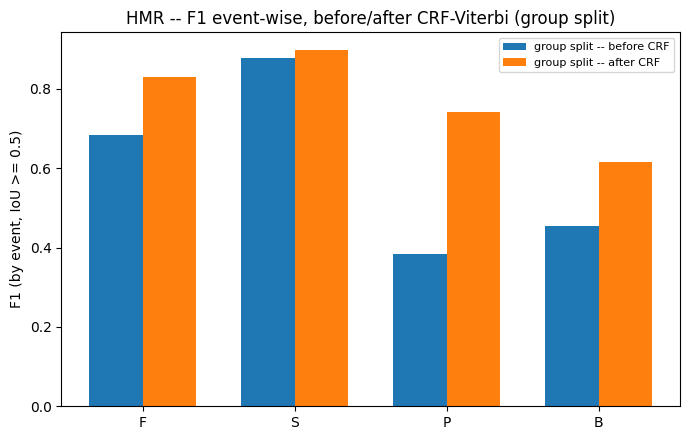

[HMR] Macro-F1 gain from CRF-Viterbi (group split) -- sample-wise: -0.0230 | event-wise: +0.1709


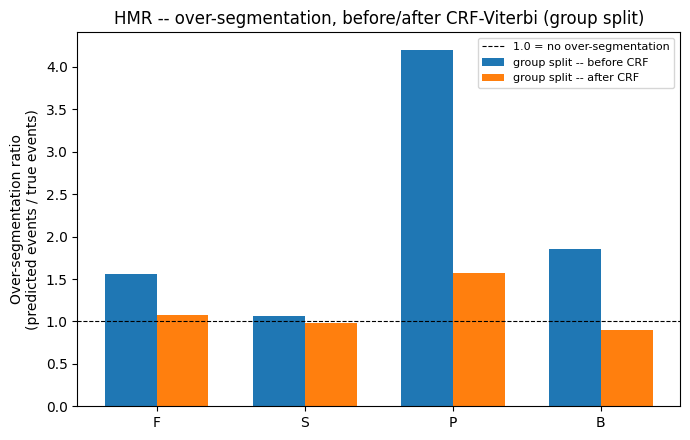

[HMR] Average over-segmentation (macro, group split) -- before CRF: 2.166 | after CRF: 1.133 | reduction: +1.032


In [29]:
delta_sample_hmr, delta_event_hmr = compare_sample_vs_event("HMR", CLASSES_4, result_hmr)
over_before_hmr, over_after_hmr = plot_oversegmentation("HMR", CLASSES_4, result_hmr)

In [30]:
sample_compare_hmr, event_compare_hmr = recap_table(CLASSES_4, result_hmr)

=== Sample-wise comparison (precision/recall/F1 by class + macro_avg) ===


,step,precision,recall,f1,support
F,group split -- before CRF,0.9590,0.9076,0.9326,71606.0
S,group split -- before CRF,0.7699,0.9083,0.8334,7075.0
P,group split -- before CRF,0.8910,0.9721,0.9298,29758.0
B,group split -- before CRF,0.7664,0.7530,0.7596,8060.0
macro_avg,group split -- before CRF,0.8466,0.8852,0.8638,116499.0
F,group split -- after CRF,0.9676,0.8615,0.9115,71606.0
S,group split -- after CRF,0.6720,0.9467,0.7860,7075.0
P,group split -- after CRF,0.8477,0.9834,0.9106,29758.0
B,group split -- after CRF,0.7464,0.7644,0.7553,8060.0
macro_avg,group split -- after CRF,0.8084,0.8890,0.8408,116499.0



=== Event-wise comparison (by class) -- before/after CRF, over-segmentation ratio included ===


,step,event_precision,event_recall,event_f1,oversegmentation_ratio
class,,,,,
F,group split -- before CRF,0.5623,0.8740,0.6844,1.5543
S,group split -- before CRF,0.8520,0.9027,0.8766,1.0595
P,group split -- before CRF,0.2382,1.0000,0.3848,4.1977
B,group split -- before CRF,0.3506,0.6489,0.4552,1.8511
F,group split -- after CRF,0.8004,0.8624,0.8302,1.0775
S,group split -- after CRF,0.9063,0.8892,0.8977,0.9811
P,group split -- after CRF,0.6074,0.9535,0.7421,1.5698
B,group split -- after CRF,0.6471,0.5851,0.6145,0.9043


## Dataset 2 -- RTC

In [ ]:
table_rtc = build_dataset_table("rtc", iterate_rtc(RTC_ROOT), limit=LIMIT_RTC)
feature_cols_rtc = [c for c in table_rtc.columns if c not in ("label", "group", "recording_id", "subject")]
X_rtc = table_rtc[feature_cols_rtc].to_numpy()
y_rtc = table_rtc["label"].to_numpy()

print(f"\n{len(table_rtc)} samples, {len(feature_cols_rtc)} features, "
      f"{table_rtc['recording_id'].nunique()} recordings, {table_rtc['group'].nunique()} participants.")
print(table_rtc["label"].value_counts())

  [rtc] PR1_SUT1 (98905 echantillons)
  [rtc] PR1_SUT2 (73966 echantillons)
  [rtc] PR2_SUT1 (123520 echantillons)
  [rtc] PR2_SUT2 (90021 echantillons)
  [rtc] PR3_SUT1 (57135 echantillons)
  [rtc] PR3_SUT2 (72098 echantillons)
  [rtc] PR4_SUT1 (65831 echantillons)
  [rtc] PR4_SUT2 (118062 echantillons)
  4293 echantillon(s) hors ['F', 'S', 'P', 'B'] ecarte(s) (ex: 'noise' RTC).

695245 echantillons, 399 features, 8 enregistrements, 4 participants.
label
F    502648
P     84237
B     57147
S     51213
Name: count, dtype: int64


In [6]:
train_mask_r_rtc, val_mask_r_rtc, test_mask_r_rtc = sample_train_val_test_split(len(table_rtc), seed=RANDOM_STATE)
print(f"Split by sample -- train={train_mask_r_rtc.sum()}, val={val_mask_r_rtc.sum()}, test={test_mask_r_rtc.sum()}")

clf_random_rtc = CascadeForestClassifier(
    n_estimators_per_forest=N_ESTIMATORS, max_layers=MAX_LAYERS, random_state=RANDOM_STATE, n_jobs=N_JOBS,
)
clf_random_rtc.fit(X_rtc[train_mask_r_rtc], y_rtc[train_mask_r_rtc], X_rtc[val_mask_r_rtc], y_rtc[val_mask_r_rtc])

sample_report_random_rtc, event_report_random_rtc, y_pred_random_rtc = evaluate_split(
    clf_random_rtc, table_rtc, X_rtc, y_rtc, test_mask_r_rtc, CLASSES_4, "RTC -- Split by sample",
    show_oversegmentation=False,
)


Split aleatoire -- train=556196, val=69524, test=69525


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 1: val macro-F1 = 0.9125


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 2: val macro-F1 = 0.9703


...

/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== RTC -- SPLIT ALEATOIRE PAR ECHANTILLON -- echantillon par echantillon ===


,precision,recall,f1,support
F,0.9890,0.9922,0.9906,50281.0
S,0.9299,0.9057,0.9177,5143.0
P,0.9897,0.9854,0.9876,8425.0
B,0.9870,0.9884,0.9877,5676.0
macro_avg,0.9739,0.9679,0.9709,69525.0



=== RTC -- SPLIT ALEATOIRE PAR ECHANTILLON -- par evenement ===
(ratio de sur-segmentation non affiche : non interpretable sur un split aleatoire, les sequences temporelles n'y sont pas intactes -- cf. Etape 2 pour ce metrique.)


,n_true_events,n_pred_events,event_precision,event_recall,event_f1
class,,,,,
F,3531,3578,0.9279,0.9402,0.9340
S,3266,3240,0.9306,0.9231,0.9268
P,725,745,0.9597,0.9862,0.9728
B,462,477,0.9497,0.9805,0.9649


In [18]:
result_rtc = run_group_split_with_crf(
    table_rtc, X_rtc, y_rtc, feature_cols_rtc, CLASSES_4, FS_HZ_RTC,
    n_estimators=N_ESTIMATORS, max_layers=MAX_LAYERS, n_jobs=N_JOBS, random_state=RANDOM_STATE,
    show_performance=False,
)

Split groupe -- train=311770, val=213357, test=170118


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 1: val macro-F1 = 0.7234


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 2: val macro-F1 = 0.6287
[CascadeForest] no improvement after layer 2, stopping at 1 layers
[CascadeForest] final model: 1 layers, best val macro-F1 = 0.7234
Physiological duration (ms) : {'F': 451.3841740377719, 'S': 47.08143712574851, 'P': 502.28241563055064, 'B': 655.1903553299492}


...

/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== BEFORE CRF-Viterbi (split group) -- by event ===


,n_true_events,n_pred_events,oversegmentation_ratio
class,,,
F,1427,1978,1.3861
S,1394,1153,0.8271
P,230,753,3.2739
B,130,154,1.1846



=== AFTER CRF-Viterbi (split group) -- by event ===


,n_true_events,n_pred_events,oversegmentation_ratio
class,,,
F,1427,1167,0.8178
S,1394,1125,0.8070
P,230,264,1.1478
B,130,126,0.9692


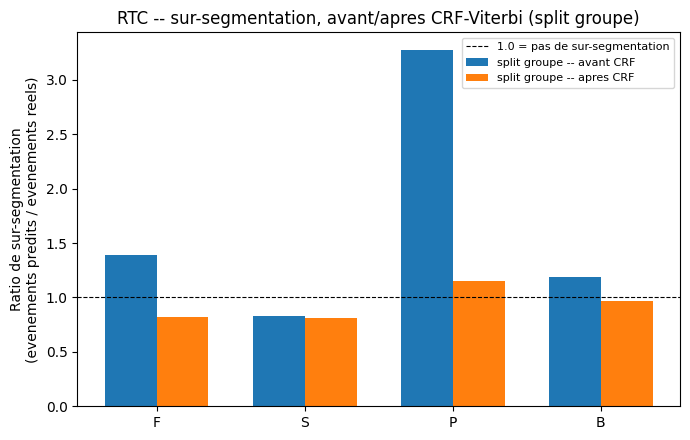

[RTC] Sur-segmentation moyenne (macro, split groupe) -- avant CRF: 1.668 | apres CRF: 0.935 | reduction: +0.732


In [8]:
over_before_rtc, over_after_rtc = plot_oversegmentation("RTC", CLASSES_4, result_rtc)

In [19]:
event_compare_rtc = oversegmentation_table(CLASSES_4, result_rtc)

=== Sur-segmentation par classe -- before/apres CRF-Viterbi (split groupe) ===


,etape,n_true_events,n_pred_events,oversegmentation_ratio
class,,,,
F,split groupe -- avant CRF,1427,1978,1.3861
S,split groupe -- avant CRF,1394,1153,0.8271
P,split groupe -- avant CRF,230,753,3.2739
B,split groupe -- avant CRF,130,154,1.1846
F,split groupe -- apres CRF,1427,1167,0.8178
S,split groupe -- apres CRF,1394,1125,0.8070
P,split groupe -- apres CRF,230,264,1.1478
B,split groupe -- apres CRF,130,126,0.9692


## Stage 2 

In [ ]:
# === Stage 2 imports
import glob
import json
from time import perf_counter
from contextlib import contextmanager

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import (
    classification_report, accuracy_score, precision_recall_curve,
    precision_recall_fscore_support,
)

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

tf.get_logger().setLevel("ERROR")


In [ ]:
# === Stage 2 configuration 
CONFIG_STAGE2 = {
    # --- Data ---
    "data_folder": str(RTC_ROOT),           # folder containing the annotated RTC CSVs
    "file_pattern": "*.csv",
    "label_column": "Class",
    "fs": FS_HZ_RTC,                        # 200.0 Hz, already defined in Stage 1
    "seed": RANDOM_STATE,

    # --- Stage 2: sliding window ---
    "stage2_window": 10,                    # best config Window = 10, stride = 1
    "stage2_stride": 1,
    "stage2_epochs_cv": 5 if QUICK else 60,    
    "stage2_epochs_final": 5 if QUICK else 60,  
    "stage2_batch_size": 32,

    # --- Stage 2: Hard Negative Mining + Focal Loss ---
    "hnm_augmentation_factor": 5,
    "hnm_initial_ratio": 5,
    "hnm_remine_every": 3,
    "focal_gamma": 3.0,
    "focal_alpha": 0.95,

    # --- Output ---
    "output_dir": str(PUPIL_ROOT / "results" / "stage2_rtc"),
}

CLASS_MAPPING_STAGE2 = {"fixation": 0, "saccade": 1, "smooth_pursuit": 2, "blink": 3, "microsaccade": 4}
REVERSE_MAPPING_STAGE2 = {v: k for k, v in CLASS_MAPPING_STAGE2.items()}

tf.keras.utils.set_random_seed(CONFIG_STAGE2["seed"])


@contextmanager
def timeit(label: str):
    """Small timing utility (cf. reference notebook, cell 7)."""
    t0 = perf_counter()
    try:
        yield
    finally:
        print(f"[OK] {label} : {perf_counter() - t0:.3f}s")


print(f"CONFIG_STAGE2 = {CONFIG_STAGE2}")


CONFIG_STAGE2 = {'data_folder': '/content/drive/MyDrive/HEMC_model/Data/data_RTC', 'file_pattern': '*.csv', 'label_column': 'classification_Kmeans', 'fs': 200.0, 'seed': 42, 'stage2_window': 20, 'stage2_stride': 1, 'stage2_epochs_cv': 5, 'stage2_epochs_final': 5, 'stage2_batch_size': 32, 'hnm_augmentation_factor': 5, 'hnm_initial_ratio': 5, 'hnm_remine_every': 3, 'focal_gamma': 3.0, 'focal_alpha': 0.95, 'output_dir': '/content/drive/MyDrive/HEMC_model/results/stage2_rtc'}


In [ ]:
def load_data_from_folder(folder_path, file_pattern, label_column, fs, class_mapping):
    '''Load all CSVs from a folder, clean and normalize the labels.'''
    print(f"Loading from: {folder_path} | pattern: {file_pattern}")
    required_columns = ["gaze x [px]", "gaze y [px]", label_column]

    csv_files = glob.glob(os.path.join(folder_path, file_pattern))
    if not csv_files:
        raise FileNotFoundError(f"No file found for pattern: {file_pattern}")

    label_aliases = {
        "f": "fixation", "fix": "fixation", "fixations": "fixation",
        "s": "saccade", "saccades": "saccade",
        "p": "smooth_pursuit", "sp": "smooth_pursuit", "pursuit": "smooth_pursuit",
        "b": "blink", "clignement": "blink",
        "micro": "microsaccade", "microsaccades": "microsaccade", "µs": "microsaccade",
        "micro saccade": "microsaccade", "micro-saccade": "microsaccade",
        "microsacade": "microsaccade", "ms": "microsaccade",
    }

    all_dfs, file_info = [], []
    with timeit("Loading + cleaning CSVs"):
        for fid, fp in enumerate(csv_files):
            df = pd.read_csv(fp)
            df = df.dropna(subset=required_columns).copy()
            df[label_column] = df[label_column].astype(str).str.strip().str.lower()
            df[label_column] = df[label_column].replace(label_aliases)
            df = df[df[label_column].isin(class_mapping.keys())].copy()

            dx = np.diff(df["gaze x [px]"], prepend=df["gaze x [px]"].iloc[0]) * fs
            dy = np.diff(df["gaze y [px]"], prepend=df["gaze y [px]"].iloc[0]) * fs
            df["velocity"] = np.sqrt(dx ** 2 + dy ** 2)
            df["file_source"] = os.path.basename(fp)
            df["file_id"] = fid

            file_info.append({
                "filename": os.path.basename(fp),
                "samples": len(df),
                "class_counts": df[label_column].value_counts().to_dict(),
            })
            all_dfs.append(df)

        data = pd.concat(all_dfs, ignore_index=True)
        print(f"Total: {len(data):,} rows across {len(all_dfs)} files")
        print(data[label_column].value_counts())
    return data, file_info


In [ ]:
# Execution (cf. reference notebook, cell 9) -- adapted to load RTC only,
# via CONFIG_STAGE2["data_folder"] = RTC_ROOT (defined in Stage 1 above).
data_stage2_rtc, file_info_stage2_rtc = load_data_from_folder(
    CONFIG_STAGE2["data_folder"], CONFIG_STAGE2["file_pattern"], CONFIG_STAGE2["label_column"],
    CONFIG_STAGE2["fs"], CLASS_MAPPING_STAGE2,
)


Chargement depuis : /content/drive/MyDrive/HEMC_model/Data/data_RTC | pattern : *.csv
Total : 1,088,865 lignes sur 14 fichiers
classification_Kmeans
fixation          791269
smooth_pursuit    136886
blink              73479
saccade            67650
microsaccade       19581
Name: count, dtype: int64
[OK] Chargement + nettoyage des CSV : 28.483s


## Sliding window

In [ ]:
def preprocess_sliding_window(data, label_column, window, stride, fs):
    '''Build the Stage 2 sliding windows (fixation vs microsaccade).'''
    half = window // 2
    segments, labels, sources = [], [], []
    n_ms, n_fix = 0, 0

    for fid in data["file_id"].unique():
        sub = data[data["file_id"] == fid].reset_index(drop=True)
        x = sub["gaze x [px]"].values.astype(np.float32)
        y = sub["gaze y [px]"].values.astype(np.float32)
        v = sub["velocity"].values.astype(np.float32)
        lbl = sub[label_column].values
        fname = sub["file_source"].iloc[0]
        n = len(sub)

        for center in range(half, n - half, stride):
            s, e = center - half, center + half
            if e > n:
                break
            center_label = lbl[center]
            if center_label not in ("microsaccade", "fixation"):
                continue
            segments.append(np.column_stack([x[s:e], y[s:e], v[s:e]]))
            labels.append(center_label)
            sources.append(fname)
            n_ms += center_label == "microsaccade"
            n_fix += center_label == "fixation"

    def to_6_channels(seg):
        x, y, _v = seg[:, 0], seg[:, 1], seg[:, 2]
        vx, vy = np.gradient(x) * fs, np.gradient(y) * fs
        speed = np.hypot(vx, vy)
        acc = np.gradient(speed) * fs
        return np.column_stack([x, y, vx, vy, speed, np.abs(acc)]).astype(np.float32)

    X = np.array([to_6_channels(s) for s in segments], dtype=np.float32) if segments else np.empty((0,))
    y = np.array(labels, dtype=object)
    groups = np.array(sources, dtype=object)

    print(f"Stage 2 windows: {len(X)} | MS: {n_ms} | Fixations: {n_fix} | ratio: {n_ms/max(n_fix,1):.3f}")
    return X, y, groups


## Hard Negative Mining progressif + ResNet1D

In [ ]:
def augment_time_series(X, jitter_std=0.3, shift_max=1, stretch_low=0.95, stretch_high=1.05,
                        p=0.8, seed=42):
    '''Time-series augmentation (jitter, shift, stretch) for the MS windows.'''
    rng = np.random.default_rng(seed)
    X_aug = X.copy()
    n, L, C = X.shape
    for i in range(n):
        if rng.random() < p:
            X_aug[i] += rng.normal(0, jitter_std, size=(L, C))
        if rng.random() < p:
            k = int(rng.integers(-shift_max, shift_max + 1))
            if k > 0:
                X_aug[i, k:, :] = X_aug[i, :-k, :]; X_aug[i, :k, :] = 0
            elif k < 0:
                k = -k
                X_aug[i, :-k, :] = X_aug[i, k:, :]; X_aug[i, -k:, :] = 0
        if rng.random() < p:
            s = float(rng.uniform(stretch_low, stretch_high))
            newL = int(round(L * s))
            idx = np.linspace(0, L - 1, newL)
            Xr = np.stack([np.interp(idx, np.arange(L), X_aug[i, :, c]) for c in range(C)], axis=1)
            if newL >= L:
                X_aug[i] = Xr[:L]
            else:
                pad = np.zeros((L, C), dtype=X.dtype); pad[:newL] = Xr; X_aug[i] = pad
    return X_aug


def prepare_hnm_dataset(X, y, groups, augmentation_factor=5, initial_ratio=5, seed=42):
    '''Augments the microsaccades and builds the initial dataset (ratio 1:initial_ratio),
    keeping a full pool of fixations for later mining.'''
    rng = np.random.default_rng(seed)
    ms_mask = y == 1
    X_ms, y_ms, groups_ms = X[ms_mask], y[ms_mask], groups[ms_mask]
    X_fix, y_fix, groups_fix = X[~ms_mask], y[~ms_mask], groups[~ms_mask]

    X_ms_list, y_ms_list, groups_ms_list = [X_ms], [y_ms], [groups_ms]
    for i in range(augmentation_factor - 1):
        X_ms_list.append(augment_time_series(X_ms, seed=seed + i))
        y_ms_list.append(y_ms.copy())
        groups_ms_list.append(groups_ms.copy())
    X_ms_aug = np.concatenate(X_ms_list)
    y_ms_aug = np.concatenate(y_ms_list)
    groups_ms_aug = np.concatenate(groups_ms_list)

    n_fix_init = min(len(X_ms_aug) * initial_ratio, len(X_fix))
    fix_idx = rng.choice(len(X_fix), size=n_fix_init, replace=False)

    X_init = np.concatenate([X_ms_aug, X_fix[fix_idx]])
    y_init = np.concatenate([y_ms_aug, y_fix[fix_idx]])
    groups_init = np.concatenate([groups_ms_aug, groups_fix[fix_idx]])

    shuffle = rng.permutation(len(X_init))
    X_init, y_init, groups_init = X_init[shuffle], y_init[shuffle], groups_init[shuffle]

    return {
        "X_init": X_init, "y_init": y_init, "groups_init": groups_init,
        "X_ms_augmented": X_ms_aug, "y_ms_augmented": y_ms_aug,
        "X_fix_pool": X_fix, "y_fix_pool": y_fix,
    }


def focal_loss(gamma=3.0, alpha=0.95):
    '''Binary focal loss, to concentrate learning on the minority class (MS).'''
    def _fl(y_true, y_pred):
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1. - eps)
        pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1. - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha, 1. - alpha)
        return -tf.reduce_mean(alpha_t * tf.pow(1. - pt, gamma) * tf.math.log(pt))
    return _fl


class ProgressiveHardNegativeMining(tf.keras.callbacks.Callback):
    '''Keras callback: periodically re-samples the negatives (fixations),
    favoring the most ambiguous ones, following a 3-phase curriculum.'''

    def __init__(self, X_pool_ms, X_pool_fix, y_pool_ms, y_pool_fix,
                 initial_ratio=5, remine_every=3, verbose=1):
        super().__init__()
        self.X_ms, self.y_ms = X_pool_ms, y_pool_ms
        self.X_fix_pool, self.y_fix_pool = X_pool_fix, y_pool_fix
        self.initial_ratio = initial_ratio
        self.remine_every = remine_every
        self.verbose = verbose
        self.fix_difficulty_scores = np.zeros(len(X_pool_fix))
        self.mining_history = []

    def _get_mining_strategy(self, epoch):
        if epoch < 15:
            return {"hard_ratio": 0.5, "phase": "Warm-up"}
        elif epoch < 40:
            return {"hard_ratio": 0.7, "phase": "Focus"}
        return {"hard_ratio": 0.8, "phase": "Fine-tune"}

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.remine_every != 0:
            return
        strategy = self._get_mining_strategy(epoch)
        scores = self.model.predict(self.X_fix_pool, verbose=0).ravel()
        alpha = 0.7
        self.fix_difficulty_scores = alpha * scores + (1 - alpha) * self.fix_difficulty_scores

        n_total = len(self.X_ms) * self.initial_ratio
        n_hard = int(n_total * strategy["hard_ratio"])
        n_easy = n_total - n_hard
        hard_idx = np.argsort(self.fix_difficulty_scores)[-n_hard:]
        easy_idx = np.argsort(scores)[:n_easy]

        self.mining_history.append({
            "epoch": epoch + 1, "phase": strategy["phase"],
            "n_hard": len(hard_idx), "n_easy": len(easy_idx),
            "hard_score_mean": float(scores[hard_idx].mean()),
            "easy_score_mean": float(scores[easy_idx].mean()),
        })
        if self.verbose:
            print(f"  Mining epoch {epoch+1} [{strategy['phase']}] "
                  f"Hard: {len(hard_idx)} ({scores[hard_idx].mean():.3f}) "
                  f"Easy: {len(easy_idx)} ({scores[easy_idx].mean():.3f})")


def build_stage2_resnet1d(win, n_ch, focal_gamma, focal_alpha, seed=42):
    '''ResNet1D with 3 dilated residual blocks (dilation 1/2/4) + binary classification head.'''
    tf.keras.utils.set_random_seed(seed)
    inp = layers.Input((win, n_ch))

    def residual_block(x, filters, kernel=3, dilation=1):
        y = layers.Conv1D(filters, kernel, padding="same", dilation_rate=dilation)(x)
        y = layers.BatchNormalization()(y)
        y = layers.ReLU()(y)
        y = layers.Conv1D(filters, kernel, padding="same", dilation_rate=dilation)(y)
        y = layers.BatchNormalization()(y)
        if x.shape[-1] != filters:
            x = layers.Conv1D(filters, 1, padding="same")(x)
        return layers.ReLU()(layers.add([x, y]))

    x = residual_block(inp, 32, kernel=5, dilation=1)
    x = residual_block(x, 64, kernel=3, dilation=2)
    x = residual_block(x, 128, kernel=3, dilation=4)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(optimizer="adam", loss=focal_loss(focal_gamma, focal_alpha), metrics=["accuracy"])
    return model


## Training (LOSO) 

In [ ]:
def train_stage2_hnm(X, y_raw, groups, config):
    '''Train the ResNet1D + HNM in LOSO (GroupKFold on files/subjects), then the final model.'''
    print("="*70, "\nSTAGE 2 — ResNet1D + Hard Negative Mining (LOSO)\n" + "="*70)
    y = np.array([1 if l == "microsaccade" else 0 for l in y_raw], dtype=int)

    hnm_data = prepare_hnm_dataset(X, y, groups,
                                    augmentation_factor=config["hnm_augmentation_factor"],
                                    initial_ratio=config["hnm_initial_ratio"], seed=config["seed"])
    X_init, y_init, groups_init = hnm_data["X_init"], hnm_data["y_init"], hnm_data["groups_init"]
    X_ms_aug, y_ms_aug = hnm_data["X_ms_augmented"], hnm_data["y_ms_augmented"]
    X_fix_pool, y_fix_pool = hnm_data["X_fix_pool"], hnm_data["y_fix_pool"]

    gkf = GroupKFold(n_splits=len(np.unique(groups_init)))
    accs, f1s, precs, recs, thr_list = [], [], [], [], []
    y_true_all, y_pred_all, y_scores_all = [], [], []

    for fold, (tr, te) in enumerate(gkf.split(X_init, y_init, groups=groups_init)):
        Xtr, Xte, ytr, yte = X_init[tr], X_init[te], y_init[tr], y_init[te]
        mu, sd = Xtr.mean(axis=(0, 1)), Xtr.std(axis=(0, 1)); sd[sd < 1e-8] = 1.0
        Xtr_n, Xte_n = (Xtr - mu) / sd, (Xte - mu) / sd
        X_ms_n, X_fix_n = (X_ms_aug - mu) / sd, (X_fix_pool - mu) / sd

        model = build_stage2_resnet1d(X_init.shape[1], X_init.shape[2],
                                      config["focal_gamma"], config["focal_alpha"],
                                      seed=config["seed"] + fold)
        callbacks = [
            EarlyStopping(patience=10, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(factor=0.5, patience=5, verbose=0),
            ProgressiveHardNegativeMining(X_ms_n, X_fix_n, y_ms_aug, y_fix_pool,
                                          initial_ratio=config["hnm_initial_ratio"],
                                          remine_every=config["hnm_remine_every"], verbose=0),
        ]
        model.fit(Xtr_n, ytr, validation_data=(Xte_n, yte), epochs=config["stage2_epochs_cv"],
                  batch_size=config["stage2_batch_size"], callbacks=callbacks, verbose=0)

        scores = model.predict(Xte_n, verbose=0).ravel()
        P, R, T = precision_recall_curve(yte, scores)
        F1 = 2 * P * R / (P + R + 1e-12)
        thr = T[np.argmax(F1)] if len(T) > 0 else 0.5
        yp = (scores >= thr).astype(int)

        prec, rec, f1, _ = precision_recall_fscore_support(yte, yp, labels=[1], average="binary", zero_division=0)
        accs.append(accuracy_score(yte, yp)); f1s.append(f1); precs.append(prec); recs.append(rec)
        thr_list.append(float(thr))
        y_true_all.extend(yte.tolist()); y_pred_all.extend(yp.tolist()); y_scores_all.extend(scores.tolist())
        print(f"  Fold {fold+1} — F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | Thr: {thr:.3f}")

    best_threshold = float(np.mean(thr_list))
    print(f"\nLOSO — F1: {np.mean(f1s):.4f} ± {np.std(f1s):.4f} | "
          f"Precision: {np.mean(precs):.4f} | Recall: {np.mean(recs):.4f} | "
          f"Accuracy: {np.mean(accs):.4f} | Optimal threshold: {best_threshold:.3f}")
    print(classification_report(y_true_all, y_pred_all, target_names=["Fixation", "Microsaccade"], zero_division=0))

    # Final model trained on the entire dataset
    mu, sd = X_init.mean(axis=(0, 1)), X_init.std(axis=(0, 1)); sd[sd < 1e-8] = 1.0
    Xn = (X_init - mu) / sd
    X_ms_n, X_fix_n = (X_ms_aug - mu) / sd, (X_fix_pool - mu) / sd
    final_model = build_stage2_resnet1d(X_init.shape[1], X_init.shape[2],
                                        config["focal_gamma"], config["focal_alpha"], seed=config["seed"])
    final_model.fit(Xn, y_init, epochs=config["stage2_epochs_final"], batch_size=config["stage2_batch_size"],
                     callbacks=[ProgressiveHardNegativeMining(X_ms_n, X_fix_n, y_ms_aug, y_fix_pool,
                                initial_ratio=config["hnm_initial_ratio"],
                                remine_every=config["hnm_remine_every"], verbose=0)], verbose=0)

    results = {
        "accuracy": float(np.mean(accs)), "f1_score": float(np.mean(f1s)), "f1_std": float(np.std(f1s)),
        "precision": float(np.mean(precs)), "recall": float(np.mean(recs)), "best_threshold": best_threshold,
        "y_true_loso": y_true_all, "y_pred_loso": y_pred_all, "y_scores_loso": y_scores_all,
    }
    norm_stats = {"mu": mu.astype(np.float32), "sd": sd.astype(np.float32)}
    return final_model, norm_stats, results


In [ ]:
def save_stage2_pipeline(output_dir, config, stage2_model, stage2_norm_stats):
    """Serialize the Stage 2 artifacts (adapted from `save_pipeline`, reference notebook,
    cell 21 -- here without the Stage 1/HMM artifacts, which are not trained in this notebook)."""
    p = Path(output_dir); p.mkdir(parents=True, exist_ok=True)
    (p / "config_stage2.json").write_text(json.dumps(config, indent=2, default=str))
    stage2_model.save(str(p / "stage2_resnet1d_hnm.keras"))
    np.savez(p / "stage2_norm_stats.npz", mu=stage2_norm_stats["mu"], sd=stage2_norm_stats["sd"])
    print(f"Stage 2 pipeline saved to: {p.resolve()}")


In [ ]:
X2_rtc, y2_raw_rtc, groups2_rtc = preprocess_sliding_window(
    data_stage2_rtc, CONFIG_STAGE2["label_column"], CONFIG_STAGE2["stage2_window"],
    CONFIG_STAGE2["stage2_stride"], CONFIG_STAGE2["fs"],
)

stage2_model_rtc, stage2_norm_stats_rtc, stage2_results_rtc = train_stage2_hnm(
    X2_rtc, y2_raw_rtc, groups2_rtc, CONFIG_STAGE2,
)

save_stage2_pipeline(CONFIG_STAGE2["output_dir"], CONFIG_STAGE2, stage2_model_rtc, stage2_norm_stats_rtc)


Fenêtres Stage 2 : 810668 | MS : 19580 | Fixations : 791088 | ratio : 0.025
STAGE 2 — ResNet1D + Hard Negative Mining (LOSO)
  Fold 1 — F1: 0.8492 | Prec: 0.9243 | Rec: 0.7853 | Thr: 0.600
  Fold 2 — F1: 0.8101 | Prec: 0.8544 | Rec: 0.7701 | Thr: 0.702
  Fold 3 — F1: 0.8483 | Prec: 0.9159 | Rec: 0.7900 | Thr: 0.567
  Fold 4 — F1: 0.7133 | Prec: 0.8047 | Rec: 0.6405 | Thr: 0.678
  Fold 5 — F1: 0.8988 | Prec: 0.9099 | Rec: 0.8880 | Thr: 0.700
  Fold 6 — F1: 0.8756 | Prec: 0.9227 | Rec: 0.8330 | Thr: 0.637
  Fold 7 — F1: 0.6681 | Prec: 0.9004 | Rec: 0.5311 | Thr: 0.852
  Fold 8 — F1: 0.8378 | Prec: 0.8998 | Rec: 0.7838 | Thr: 0.601
  Fold 9 — F1: 0.6614 | Prec: 0.9825 | Rec: 0.4985 | Thr: 0.832
  Fold 10 — F1: 0.9200 | Prec: 0.9227 | Rec: 0.9172 | Thr: 0.629
  Fold 11 — F1: 0.8743 | Prec: 0.9332 | Rec: 0.8225 | Thr: 0.709
  Fold 12 — F1: 0.8928 | Prec: 0.9380 | Rec: 0.8517 | Thr: 0.652
  Fold 13 — F1: 0.9099 | Prec: 0.9222 | Rec: 0.8979 | Thr: 0.694
  Fold 14 — F1: 0.7892 | Prec: 0.8772 |